# Extracting ACS MIR spectra from the LATMOS FITS files

In this notebook, we show an example of how to extract ACS MIR solar occultation transmission spectra from the Level 2 calibrated data produced at [LATMOS](https://acs.projet.latmos.ipsl.fr/en/data).  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import acs

### 1. Inputs

In [9]:
data_path = "/srv/workspace/data/tgo/acs/mir/latmos/level_2/"  #Path to the directory where the level 2 data is stored
filename = "MIR_2B_ORB018710_N1_I_P1_04000_F.fits.fz"          #Name of the FITS file

order = 223                 #Diffraction order to extract from the data
irows = [0,1,2,3,4,5,6,7]   #Index of the rows (above the slit edge) we want to extract

iki_geometry = False

### 2. Extracting the data

In [10]:
help(acs.mir.latmos.files.extract_order)

Help on function extract_order in module acs.mir.latmos.files:

extract_order(filename, ordersel, irows, refalt=180.0, iki_geometry=False, shift_row_edge=0)
    FUNCTION NAME : extract_order()
    
    DESCRIPTION : Function to extract a set of detector rows within a selected diffraction order 
                   from the LATMOS FITS files
    
    INPUTS : 
    
        filename :: Name of the input FITS file
        ordersel :: Diffraction order
        irows(nrows) :: Index of row above the usable ones
    
    OPTIONAL INPUTS:
    
        refalt :: Reference above which to calculate the uncertainty for the topmost spectra (km)
        iki_geometry :: If True, the geometry is calculated using the IKI method. If False, the geometry is calculated using the LATMOS method.
        shift_row_edge :: Number of rows to shift the bottom edge of the slit for the computation of the geometry.
            
    OUTPUTS : 
    
        lat :: Latitude 
        lon :: Longitude
        Ls :: Sola

In [7]:
lat,lon,Ls,Loct,waven,trans,transerr,tanhe = acs.mir.latmos.files.extract_order(data_path+filename,order,irows)

### 3. Making summary plots

#### Single row at all altitudes

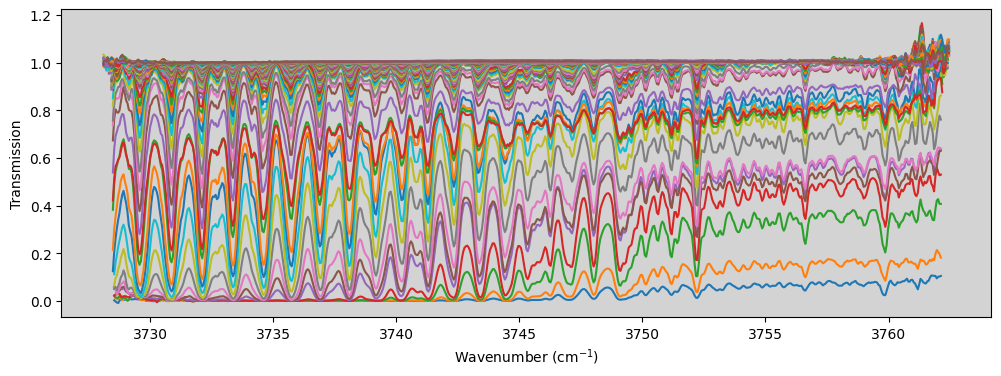

In [14]:
fig,ax1 = plt.subplots(1,1,figsize=(12,4))

irow = 4

for igeom in range(tanhe.shape[0]):
    ax1.plot(waven,trans[:,igeom,irow])

ax1.set_xlabel("Wavenumber (cm$^{-1}$)")
ax1.set_ylabel("Transmission")
ax1.set_facecolor("lightgray")

#### All rows at a single altitude

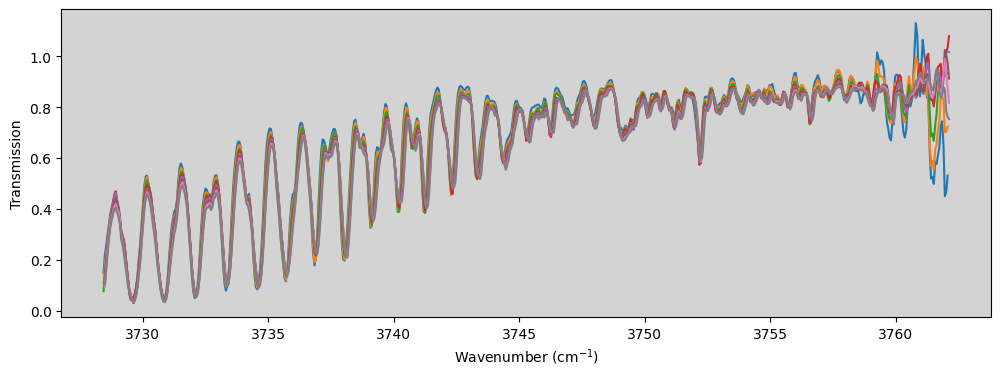

In [16]:
fig,ax1 = plt.subplots(1,1,figsize=(12,4))

igeom = 10

for irow in range(tanhe.shape[1]):
    ax1.plot(waven,trans[:,igeom,irow])

ax1.set_xlabel("Wavenumber (cm$^{-1}$)")
ax1.set_ylabel("Transmission")
ax1.set_facecolor("lightgray")